### Multi-Layer Perceptron

Gamma/Neutron Discriminator (G/N)

In [1]:
import pandas as pd
import numpy as np
from pynq import Overlay, allocate
from utils import *

Load overlay

In [2]:
# Load the FPGA hardware design (bitstream + metadata).
# The file "bd_wrapper_gn.xsa" was generated by Vivado and contains:
#   - The PL bitstream
#   - Hardware handoff information (address map, IP configuration)
#   - AXI interconnect descriptions used by PYNQ
#
# Loading the Overlay configures the programmable logic (PL) and
# exposes the hardware IP blocks as Python-accessible objects.
ol = Overlay("bd_wrapper_gn.xsa")


Explore available IP cores

In [3]:
# List all IP cores available in the loaded overlay.
# 'ip_dict' is a dictionary autogenerated by PYNQ, where:
#   - keys   = IP core names (as synthesized in Vivado)
#   - values = metadata (address ranges, driver info, registers, etc.)
#
# This is useful for discovering the names of DMA blocks, peripherals, and custom accelerators.
list(ol.ip_dict.keys())


['axi_dma_0', 'myproject_gn_accel_0', 'zynq_ultra_ps_e_0']

Create objects


In [4]:
# Get a reference to the AXI DMA instance defined in the hardware design.
# The name 'axi_dma_0' must match the IP name inside the Vivado block design.
dma = ol.axi_dma_0

# DMA channels:
#   - sendchannel:  transfers data from PS to PL  (input to accelerator)
#   - recvchannel:  transfers data from PL to PS  (output from accelerator)
dma_send = dma.sendchannel
dma_recv = dma.recvchannel

# Get a reference to the custom accelerator IP core.
# 'myproject_gn_accel_0' is the name Vivado generated for the HLS module.
# This gives access to its AXI-Lite control registers (e.g., start, status).
ip = ol.myproject_gn_accel_0

IP_CTRL_REG = 0x00  # Control register: writing 1 triggers inference

Load testing dataset

Gamma/Neutron testing dataset is stored in a csv file. Normalization is no requiered for this project.

In [5]:
# Load the raw test dataset.
# The CSV file has no header row, and the last column contains the class labels
# except for a row where the label appears as the string "class" (likely a header artifact).
df = pd.read_csv("gn_test.csv", header=None)

# Remove any rows where the last column contains the string "class".
# This cleans up header-like artifacts inside the file.
df = df[df.iloc[:, -1] != "class"].reset_index(drop=True)

# Split into features (all columns except last) and labels (last column).
# Convert to int32 so that data types match the FPGA input format.
X = df.iloc[:, :-1].astype(np.int32).to_numpy()
y_true = df.iloc[:, -1].astype(np.int32).to_numpy()

# Get dataset dimensions for verification.
num_samples = X.shape[0]
num_features = X.shape[1]

print("Samples:", num_samples)
print("Features:", num_features)


Samples: 1798
Features: 161


Define DMA buffers

In [6]:
# Number of output classes for this model.
# Binary classification: 0 = gamma, 1 = neutron.
NCLASSES = 2

# Allocate DMA-compatible input buffer for the accelerator.
# The input consists of `num_features` integer values per sample.
# Using dtype=int32 matches the accelerator's AXI interface word width.
in_buffer = allocate(shape=(num_features,), dtype=np.int32)

# Allocate DMA-compatible output buffer.
# The FPGA produces two logits/scores (one per class).
out_buffer = allocate(shape=(NCLASSES,), dtype=np.int32)

# Array to store the predicted class for each sample.
# Each prediction is an integer: 0 (gamma) or 1 (neutron).
y_pred = np.zeros(num_samples, dtype=np.int32)


Inference process

In [7]:
for i, sample in enumerate(X):
    
    # Copy the input sample into the DMA input buffer (host → device)
    in_buffer[:] = sample
    
    # 1. Start the inference IP core via control register
    ip.write(IP_CTRL_REG, 1)
    
    # 2. Prepare the DMA RX channel to receive the output from the IP
    dma.recvchannel.transfer(out_buffer)
    
    # 3. Send the input data to the IP via the DMA TX channel
    dma.sendchannel.transfer(in_buffer)
    dma.sendchannel.wait()   # Block until the TX transfer finishes
    
    # 4. Wait for the IP output to be fully received
    dma.recvchannel.wait()
    
    # 5. Select the predicted class based on the maximum output value
    y_pred[i] = np.argmax(out_buffer)

Confusion Matrix

In [8]:
# Compute the confusion matrix for binary classification.
# `y_true` : ground-truth labels (0 = gamma, 1 = neutron)
# `y_pred` : predicted labels from the FPGA
# The last argument '2' specifies the number of classes.
cm = confusion_matrix_np(y_true, y_pred, 2)
print_confusion_matrix(cm)


Confusion Matrix:
    Pred:     0     1
True  0:   895     4
True  1:    40   859


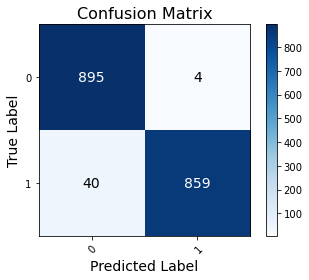

In [9]:
plot_confusion_matrix(cm, class_names=range(2))

----

This work was supported in part by the [AMD University Program](https://www.amd.com/en/corporate/university-program.html) 